# Cell 1 – Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Better visuals
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100

# Supress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Cell 2 – Load & Initial Inspection

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nMissing values:\n", df.isna().sum())
print("\nFirst 5 rows:")
display(df.head())

Shape: (7043, 21)

Columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Cell 3 – Early Data Cleaning (critical fixes first)

In [3]:
# Working copy
df_clean = df.copy()

# 1. Fix TotalCharges – convert to numeric, coerce errors → NaN
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'], errors='coerce')

# 2. Fill missing TotalCharges with 0 (logical for tenure == 0)
df_clean['TotalCharges'] = df_clean['TotalCharges'].fillna(0)

# 3. Fix obvious data error in PaperlessBilling
df_clean['PaperlessBilling'] = df_clean['PaperlessBilling'].replace('Two year', 'Yes')

# 4. Convert Churn to binary early (1 = churned)
df_clean['Churn'] = df_clean['Churn'].map({'Yes': 1, 'No': 0})

# 5. Drop useless ID
df_clean = df_clean.drop(columns=['customerID'])

print("After cleaning:")
print("Shape:", df_clean.shape)
print("\nChurn rate:", df_clean['Churn'].mean().round(4), f"({df_clean['Churn'].mean()*100:.2f}%)")
print("\nRemaining missing values:\n", df_clean.isna().sum())

After cleaning:
Shape: (7043, 20)

Churn rate: 0.2654 (26.54%)

Remaining missing values:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


### 2. Target Variable Preparation & Categorical Overview

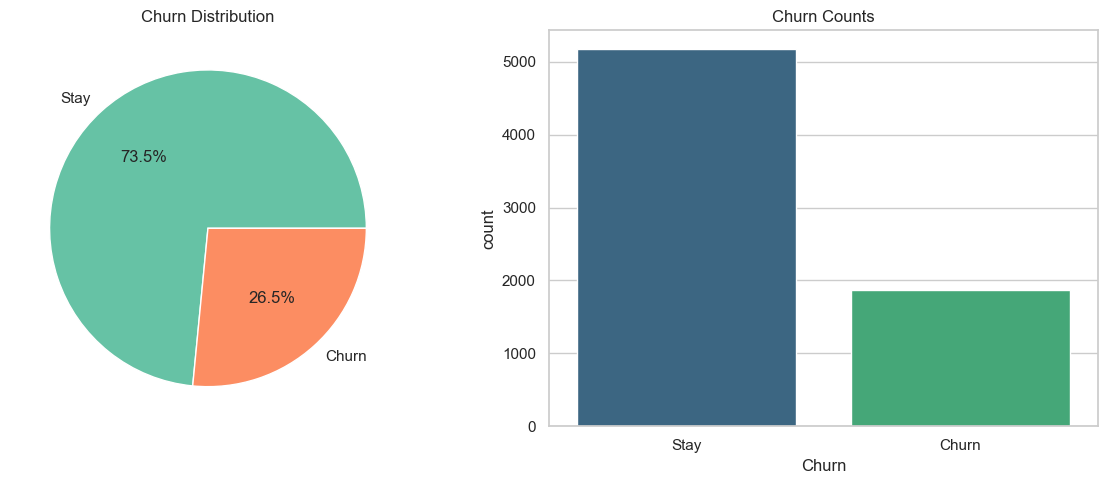

Churn rate: 26.54%


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Pie
df_clean['Churn'].value_counts().plot.pie(
    ax=ax[0], autopct='%1.1f%%', colors=['#66c2a5','#fc8d62'],
    labels=['Stay','Churn'], title='Churn Distribution'
)

# Count
sns.countplot(data=df_clean, x='Churn', ax=ax[1], palette='viridis')
ax[1].set_title('Churn Counts')
ax[1].set_xticklabels(['Stay','Churn'])

plt.tight_layout()
plt.show()

print("Churn rate:", f"{df_clean['Churn'].mean()*100:.2f}%")

# Cell 5 – Numerical Features – Distributions & Outliers

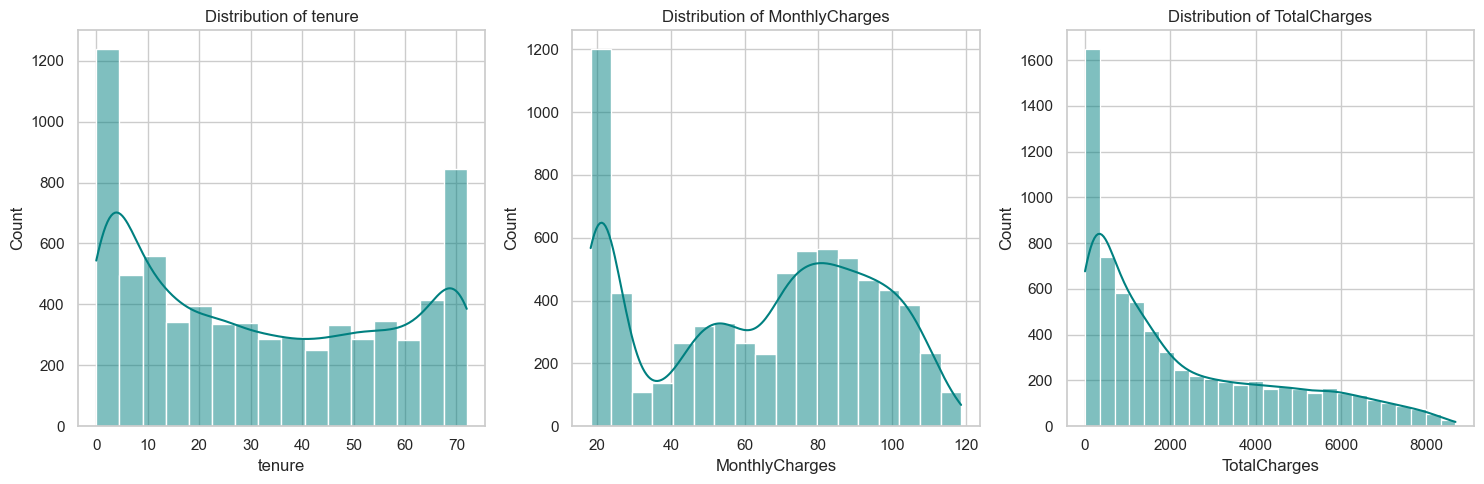

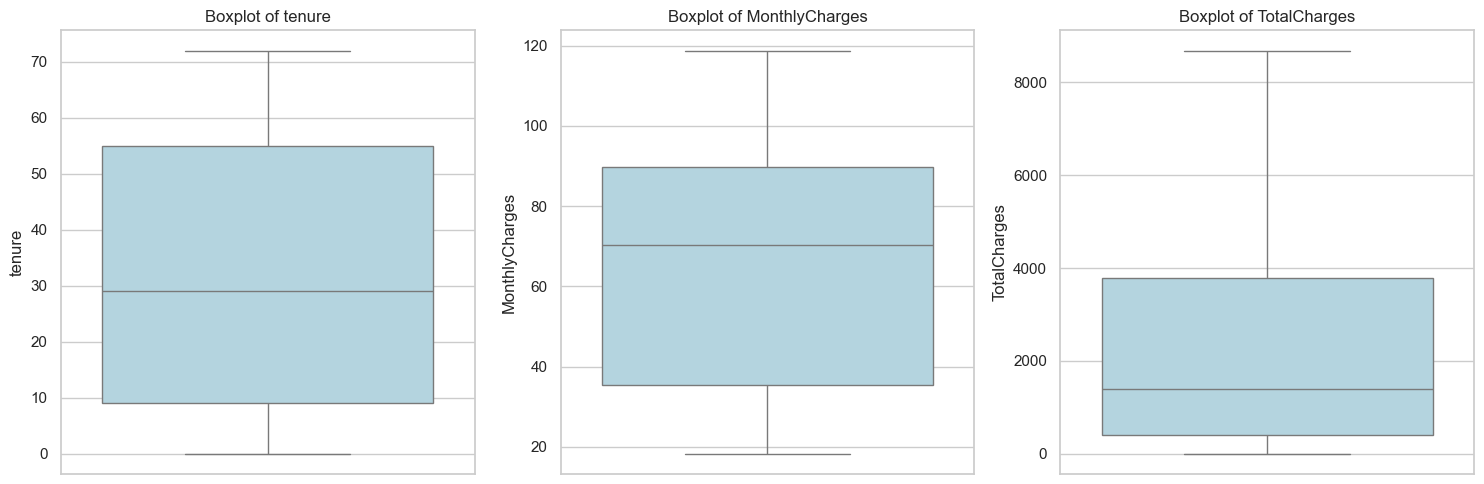

In [5]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(num_cols):
    sns.histplot(data=df_clean, x=col, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

# Boxplots to spot outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(num_cols):
    sns.boxplot(data=df_clean, y=col, ax=axes[i], color='lightblue')
    axes[i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

# Cell 6 – Categorical Overview (clean & concise)

In [6]:
# Cell 6 – Smart Categorical Audit (Industry Style)
print("=== CATEGORICAL AUDIT ===\n")

cat_cols = [
    'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaperlessBilling', 'PaymentMethod'
]

audit = []
for col in cat_cols:
    vc = df_clean[col].value_counts(dropna=False)
    pct = vc / len(df_clean) * 100
    top = vc.index[0]
    churn_rate = df_clean.groupby(col)['Churn'].mean().round(3)
    
    audit.append({
        'Feature': col,
        'Unique': len(vc),
        'Top Category': top,
        'Top %': pct.iloc[0].round(1),
        'Churn Rate Range': f"{churn_rate.min():.1%} – {churn_rate.max():.1%}"
    })

audit_df = pd.DataFrame(audit)
display(audit_df.sort_values('Unique', ascending=False))

# Highlight potential issues
print("\nPotential Data Issues:")
if 'Two year' in df_clean['PaperlessBilling'].unique():
    print("WARNING: 'Two year' still exists in PaperlessBilling!")

=== CATEGORICAL AUDIT ===



,Feature,Unique,Top Category,Top %,Churn Rate Range
15,PaymentMethod,4,Electronic check,33.6,15.2% – 45.3%
6,InternetService,3,Fiber optic,44.0,7.4% – 41.9%
5,MultipleLines,3,No,48.1,24.9% – 28.6%
7,OnlineSecurity,3,No,49.7,7.4% – 41.8%
9,DeviceProtection,3,No,43.9,7.4% – 39.1%
10,TechSupport,3,No,49.3,7.4% – 41.6%
8,OnlineBackup,3,No,43.8,7.4% – 39.9%
11,StreamingTV,3,No,39.9,7.4% – 33.5%
13,Contract,3,Month-to-month,55.0,2.8% – 42.7%
12,StreamingMovies,3,No,39.5,7.4% – 33.7%



Potential Data Issues:


# Cell 7 – Feature Engineering

In [7]:
# 1. TotalServices – count of add-on / protection services
add_on_cols = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df_clean['TotalServices'] = (df_clean[add_on_cols] == 'Yes').sum(axis=1)

# 2. RFM-inspired scores
# Recency: higher = newer = higher risk
df_clean['Recency_score'] = pd.cut(
    df_clean['tenure'],
    bins=[-1, 6, 12, 24, 48, np.inf],
    labels=[5, 4, 3, 2, 1],
    include_lowest=True
).astype(int)

# Frequency: number of add-ons (excluding core phone/internet)
df_clean['Frequency_score'] = df_clean['TotalServices']

# Monetary: binned monthly spend
df_clean['Monetary_score'] = pd.cut(
    df_clean['MonthlyCharges'],
    bins=[-1, 30, 60, 90, 120, np.inf],
    labels=[1, 2, 3, 4, 5],
    include_lowest=True
).astype(int)

print("RFM features added. Sample:")
display(df_clean[['tenure', 'TotalServices', 'Recency_score', 'Frequency_score', 'Monetary_score', 'Churn']].head(8))

RFM features added. Sample:


,tenure,TotalServices,Recency_score,Frequency_score,Monetary_score,Churn
0,1,1,5,1,1,0
1,34,2,2,2,2,0
2,2,2,5,2,2,1
3,45,3,2,3,2,0
4,2,0,5,0,3,1
5,8,3,4,3,4,1
6,22,2,3,2,3,0
7,10,1,4,1,1,0


# Cell 8 – Key Bivariate: Churn by Tenure Group

Churn by Tenure Group:


,Customers,mean,Churn%
tenure,,,
0-6m,1481,0.53,52.94
6-12m,705,0.36,35.89
1-2y,1024,0.29,28.71
2-3y,832,0.22,21.63
3-4y,762,0.19,19.03
4-5y,832,0.14,14.42
5y+,1407,0.07,6.61


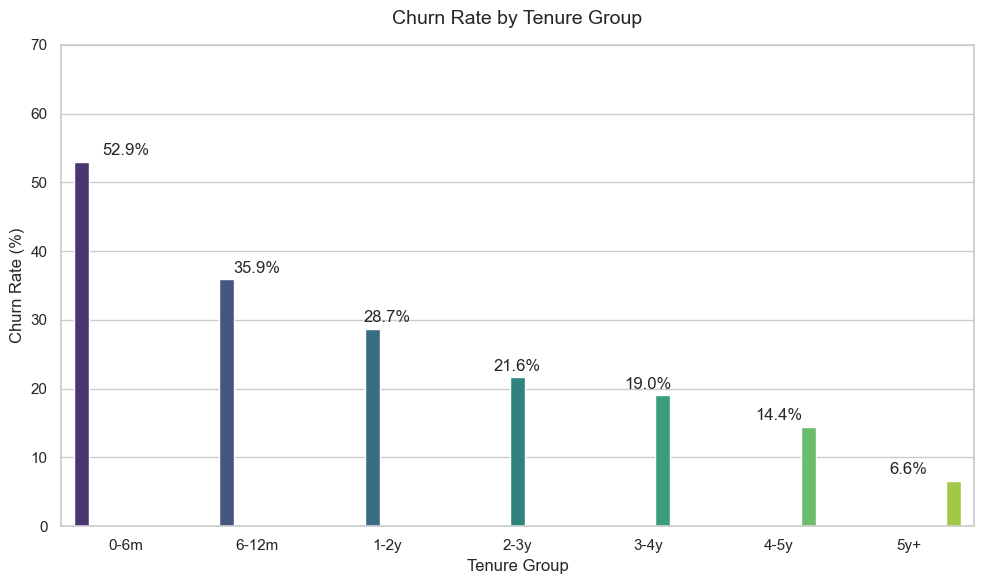

In [8]:
tenure_bins = pd.cut(
    df_clean['tenure'],
    bins=[0, 6, 12, 24, 36, 48, 60, np.inf],
    labels=['0-6m', '6-12m', '1-2y', '2-3y', '3-4y', '4-5y', '5y+'],
    include_lowest=True
)

churn_by_tenure = df_clean.groupby(tenure_bins)['Churn'].agg(['count', 'mean'])
churn_by_tenure['Churn%'] = churn_by_tenure['mean'] * 100
churn_by_tenure = churn_by_tenure.rename(columns={'count': 'Customers'})

print("Churn by Tenure Group:")
display(churn_by_tenure.round(2))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(
    x=churn_by_tenure.index,
    y=churn_by_tenure['Churn%'],
    hue=churn_by_tenure.index,
    palette='viridis',
    legend=False
)
plt.title('Churn Rate by Tenure Group', fontsize=14, pad=15)
plt.ylabel('Churn Rate (%)')
plt.xlabel('Tenure Group')
plt.ylim(0, 70)

# Add value labels
for i, v in enumerate(churn_by_tenure['Churn%']):
    plt.text(i, v + 1, f"{v:.1f}%", ha='center')

plt.tight_layout()
plt.show()

# Cell 9 – Churn by Number of Services (corrected & improved)

Churn by Number of Add-on Services:


,Customers,ChurnRate,Churn%
TotalServices,,,
0,2219,0.21,21.41
1,966,0.46,45.76
2,1033,0.36,35.82
3,1118,0.27,27.37
4,852,0.22,22.30
5,571,0.12,12.43
6,284,0.05,5.28


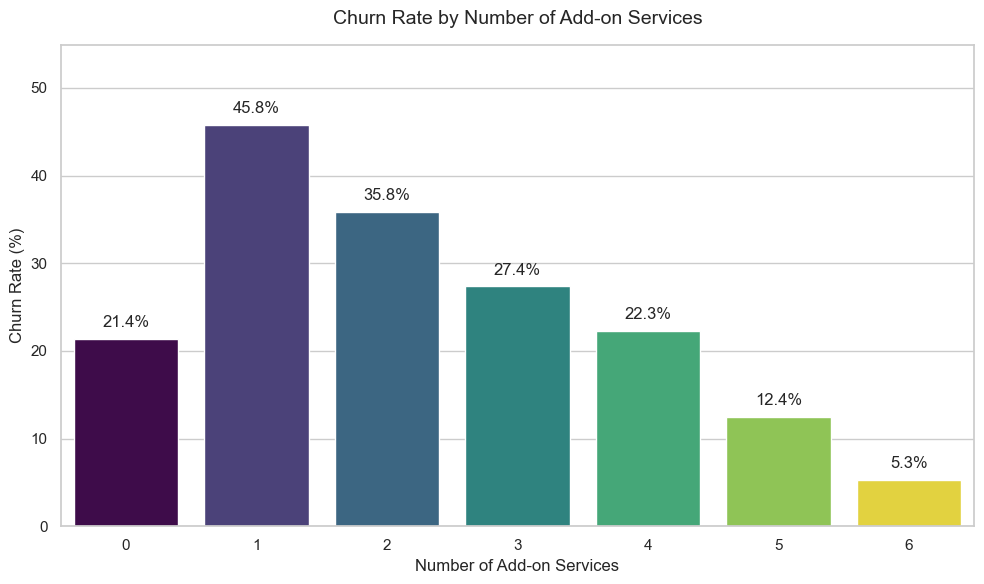

In [9]:
churn_by_services = (
    df_clean.groupby('TotalServices')['Churn']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'Customers', 'mean': 'ChurnRate'})
)

churn_by_services['Churn%'] = churn_by_services['ChurnRate'] * 100

print("Churn by Number of Add-on Services:")
display(churn_by_services.round(2))

# Plot
plt.figure(figsize=(10, 6))
bars = sns.barplot(
    data=churn_by_services.reset_index(),
    x='TotalServices',
    y='Churn%',
    hue='TotalServices',
    palette='viridis',
    legend=False
)

plt.title('Churn Rate by Number of Add-on Services', fontsize=14, pad=15)
plt.xlabel('Number of Add-on Services')
plt.ylabel('Churn Rate (%)')

# Correct annotations
for bar in bars.patches:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center', va='bottom'
    )

plt.ylim(0, churn_by_services['Churn%'].max() * 1.2)
plt.tight_layout()
plt.show()

# Cell 10 – More Important Bivariate Views (added)


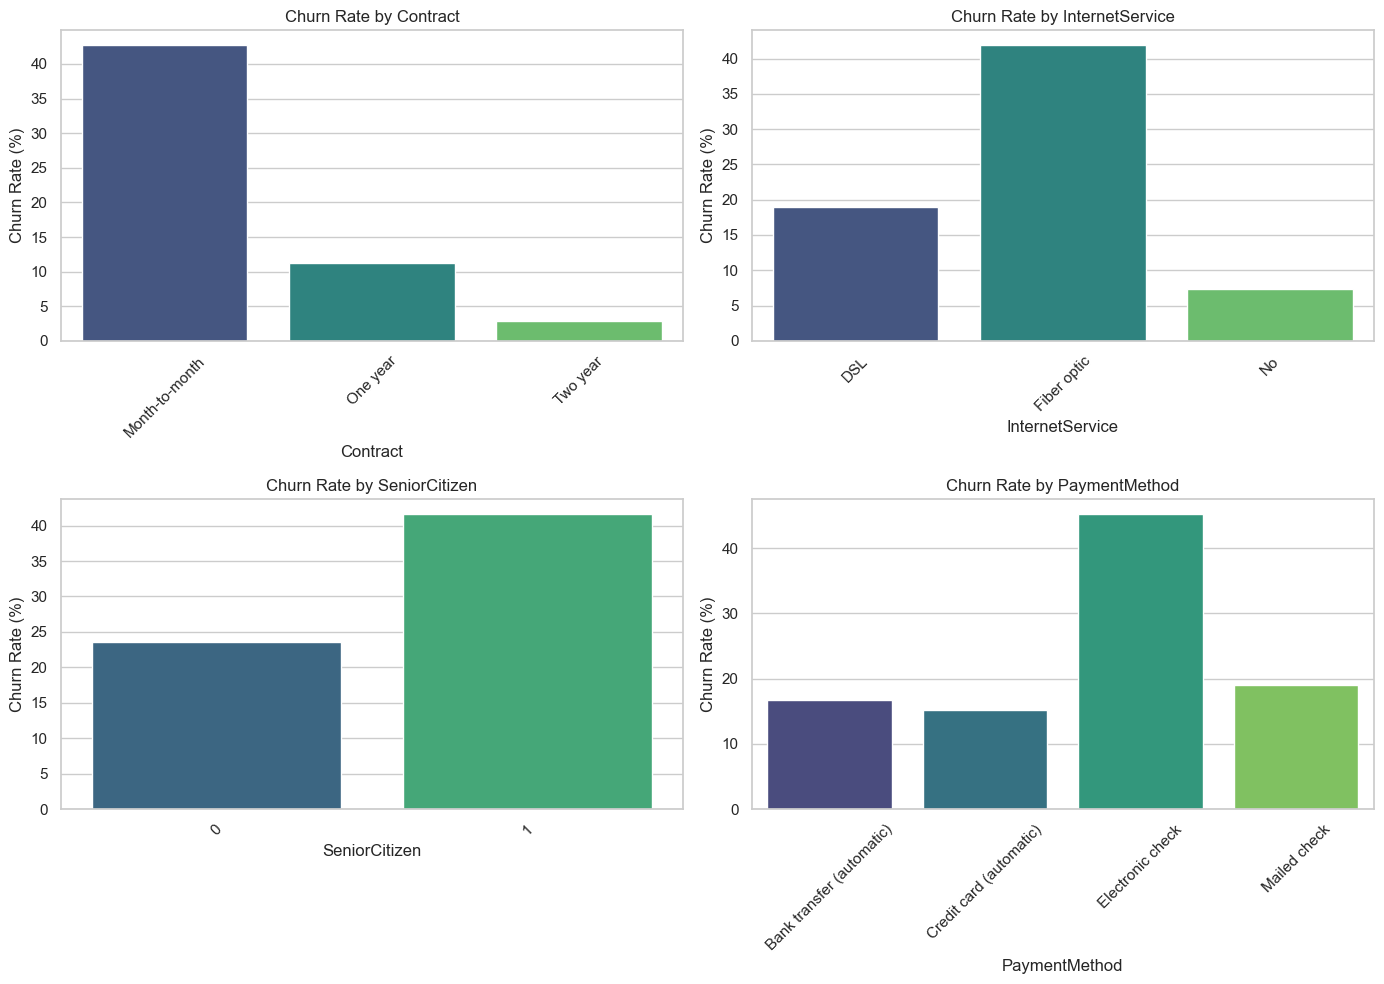

In [10]:
important_cats = ['Contract', 'InternetService', 'SeniorCitizen', 'PaymentMethod']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(important_cats):
    row, col_idx = divmod(i, 2)
    churn_rates = df_clean.groupby(col)['Churn'].mean() * 100
    sns.barplot(x=churn_rates.index, y=churn_rates.values, ax=axes[row, col_idx], palette='viridis')
    axes[row, col_idx].set_title(f'Churn Rate by {col}')
    axes[row, col_idx].set_ylabel('Churn Rate (%)')
    axes[row, col_idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Correlation Analysis

=== FEATURES MOST CORRELATED WITH CHURN ===

Top 10 Drivers of Churn (Positive Correlation):
Contract_Month-to-month           0.405
Recency_score                     0.360
OnlineSecurity_No                 0.343
TechSupport_No                    0.337
InternetService_Fiber optic       0.308
PaymentMethod_Electronic check    0.302
Monetary_score                    0.196
MonthlyCharges                    0.193
SeniorCitizen                     0.151
Frequency_score                  -0.088
Name: Churn, dtype: float64

Top 5 Retention Factors (Negative Correlation):
OnlineSecurity_No internet service   -0.228
TechSupport_No internet service      -0.228
InternetService_No                   -0.228
Contract_Two year                    -0.302
tenure                               -0.352
Name: Churn, dtype: float64


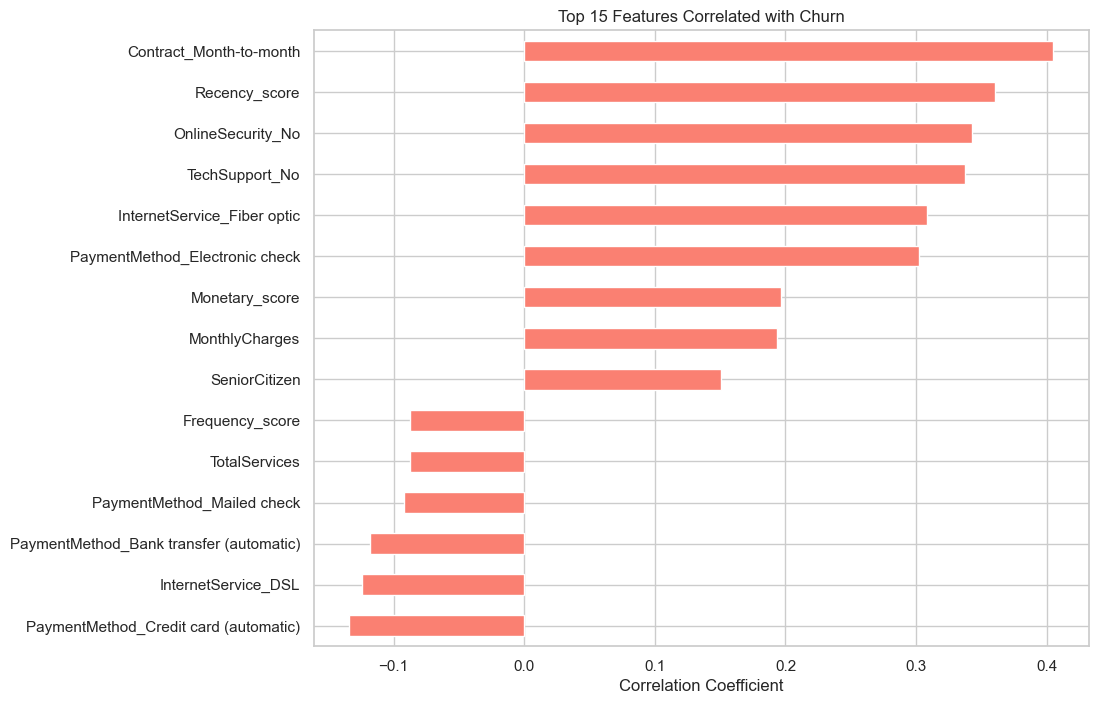

In [11]:
# Cell 11 – Correlation Analysis (Optimized for Reliability)
print("=== FEATURES MOST CORRELATED WITH CHURN ===\n")

# 1. Select categories that showed anomalies/insights in the 'copy' notebook
key_cats = ['Contract', 'InternetService', 'PaymentMethod', 'OnlineSecurity', 'TechSupport', 'SeniorCitizen']

# 2. Use drop_first=False for EDA (more reliable because you see every category's weight)
encoded = pd.get_dummies(df_clean[key_cats], drop_first=False)

# 3. Combine with numerical & engineered features from 01_eda.ipynb
corr_ready = pd.concat([
    df_clean[['tenure', 'MonthlyCharges', 'TotalCharges', 'TotalServices', 
              'Recency_score', 'Frequency_score', 'Monetary_score', 'Churn']],
    encoded
], axis=1)

# 4. Calculate and Plot
churn_corr = corr_ready.corr()['Churn'].sort_values(ascending=False)

# Remove 'Churn' itself from the list
churn_corr = churn_corr.drop('Churn')

# Display Top and Bottom
print("Top 10 Drivers of Churn (Positive Correlation):")
print(churn_corr.head(10).round(3))
print("\nTop 5 Retention Factors (Negative Correlation):")
print(churn_corr.tail(5).round(3))

# VISUALIZATION (This makes the output "Reliable" and easy to present)
plt.figure(figsize=(10, 8))
churn_corr.head(15).plot(kind='barh', color='salmon').invert_yaxis()
plt.title('Top 15 Features Correlated with Churn')
plt.xlabel('Correlation Coefficient')
plt.show()

## Statistical Tests

In [12]:
# New Cell 12 – Chi-Square Test (fixed for Pandas 2.x)
from scipy.stats import chi2_contingency

print("=== CHI-SQUARE TEST: Which categories significantly relate to Churn? ===\n")

chi_results = []
for col in cat_cols:
    table = pd.crosstab(df_clean[col], df_clean['Churn'])
    chi2, p_value, dof, expected = chi2_contingency(table)
    sig = "Yes" if p_value < 0.001 else "Yes (weak)" if p_value < 0.05 else "No"
    chi_results.append({
        'Feature': col,
        'p-value': f"{p_value:.6f}",
        'Significant (p<0.05)': sig,
        'Chi2 statistic': round(chi2, 1)
    })

chi_df = pd.DataFrame(chi_results).sort_values('p-value')

# Styling compatible with Pandas 2.x
def highlight_sig(val):
    if val in ['Yes', 'Yes (weak)']:
        return 'background-color: #d4edda'
    return ''

styled = chi_df.style.map(highlight_sig, subset=['Significant (p<0.05)'])

display(styled)

=== CHI-SQUARE TEST: Which categories significantly relate to Churn? ===



,Feature,p-value,Significant (p<0.05),Chi2 statistic
1,SeniorCitizen,0.000000,Yes,159.400000
2,Partner,0.000000,Yes,158.700000
3,Dependents,0.000000,Yes,189.100000
6,InternetService,0.000000,Yes,732.300000
7,OnlineSecurity,0.000000,Yes,850.000000
8,OnlineBackup,0.000000,Yes,601.800000
9,DeviceProtection,0.000000,Yes,558.400000
10,TechSupport,0.000000,Yes,828.200000
11,StreamingTV,0.000000,Yes,374.200000
12,StreamingMovies,0.000000,Yes,375.700000


# Cell 11 – Save Clean Version

In [13]:
processed_path = '../data/processed/telco_churn_clean_v2.csv'
df_clean.to_csv(processed_path, index=False)

print(f"Saved to: {processed_path}")
print(f"Final shape: {df_clean.shape}")
print("\nColumns:", df_clean.columns.tolist())

Saved to: ../data/processed/telco_churn_clean_v2.csv
Final shape: (7043, 24)

Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'TotalServices', 'Recency_score', 'Frequency_score', 'Monetary_score']
